Jeremy Barton <br>
03.08.2026

# Analyzing Government Spending Relative to Industry Wages: A Multi-Source Data Pipeline Encompassing Extraction, Cleaning, Storage, and Visualization

The goal of this notebook is to collect, store and visualize public data from three sources within a database. Before we can store and query the wage, spending and treasury data it must be in a dataframe form.

## Step 1: Gathering the Sources

### `treasury_df`

In [1]:
from bs4 import BeautifulSoup

#### Preprocessing

We could pass a file handler directly to the constructor of the BeautifulSoup
object and it will read the contents from the file that the handler is attached to.

Up until now only specific tags have been used to extrct data from webpages. BeautifulSoup also allows us to extract tags of the same type. Below is an example of using the `table` method to pull tags related to tables on the web. `<tr>`, `<td>`, `<th>`...

In [4]:
# Open the file
with open("data/Monthly Treasury Statement.html") as mts:
    soup = BeautifulSoup(mts)
    print(type(soup))

# Find paragraphs
all_ps = soup.find_all('p')
table = soup.table # Find tables
children = table.children # Find child elements of table
des = table.descendants # Find table descendants

<class 'bs4.BeautifulSoup'>


#### Extraction

In the first attempt to extract data from the data table, only the first table was returned. This is class being accessed contains multiple tables. Inspecting the page can help identify the right parts of a webpage to pull the correct information. This is a more direct approach, as tables can be held in 'classes' which can be accessed to find data tables. 

Now we will use the .select() method from `bs4` to search inside a DIV for tables.

In [5]:
# Inside the .select() is where the div we want to search
#   for is placed.
tables = soup.select(
    "div.data-table-module--overlayContainerNoFooter--a46b8 table"
)

table = []
# Save output for use in next step
# Creating a loop to pick up all tables in the DIV
for table in tables:
    
     table.append(table.prettify())

# Making "table" equal to tables[1] will extract the
#   uneeded download file table.
table = tables[0]
# print(table)


#### Conversion

In [6]:
import pandas as pd

Separate headers from the data.

In [7]:
rows = table.find_all('tr')[1:]
# Correct: headers is a <tr> tag
headers = table.find('tr')  # do NOT call getText() here
col_headers = [th.getText() for th in headers.findAll('th')]
# col_headers

/tmp/ipykernel_18458/3079059324.py:4: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  col_headers = [th.getText() for th in headers.findAll('th')]


In [8]:
data_rows = []

# Clean row data to only include text inside 'td' or 'th' tags.
for row in rows:
    
    cells = [cell.get_text(strip=True) for cell in row.find_all(['td', 'th'])]
    data_rows.append(cells)
# data_rows

Carefully place the row data into a pandas dataframe.

In [9]:
treasury_data = [[td.getText() for td in tr.findAll('td')] \
            for tr in rows]
# df_data

/tmp/ipykernel_18458/2943969321.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  treasury_data = [[td.getText() for td in tr.findAll('td')] \


In [10]:
treasury_df = pd.DataFrame(treasury_data, columns=col_headers)

# strip whitespace from headers
treasury_df.columns = treasury_df.columns.str.strip()

treasury_df.head()


,Record Datemm/dd/yyyy - mm/dd/yyyy,Parent ID​,Classification ID​,Classification Description​,Current Month Gross Receipts Amount​,Current Month Gross Outlay Amount​,Current Month Deficit Surplus Amount​,Table Number​,Source Line Number​,Print Order Sequence Number​,...,Data Type Code​,Record Type Code​,Sequence Level Number​,Sequence Number Code​,Fiscal Year​,Fiscal Quarter Number​,Calendar Year​,Calendar Quarter Number​,Calendar Month Number​,Calendar Day Number​
0,12/31/2025,,57633926,FY 2025,,,,1,1,1,...,S,SL,1,1,2026,1,2025,4,12,31
1,12/31/2025,57633926,57633931,October,"$326,770,236,058.10","$584,220,273,025.31","$257,450,036,967.21",1,2,2,...,D,MTH,2,1.1,2026,1,2025,4,12,31
2,12/31/2025,57633926,57633935,November,"$301,754,299,812.79","$668,517,135,060.47","$366,762,835,247.68",1,3,3,...,D,MTH,2,1.2,2026,1,2025,4,12,31
3,12/31/2025,57633926,57633940,December,"$454,414,708,491.47","$541,146,327,504.76","$86,731,619,013.29",1,4,4,...,D,MTH,2,1.3,2026,1,2025,4,12,31
4,12/31/2025,57633926,57633942,January,"$513,294,342,651.93","$641,934,549,325.42","$128,640,206,673.49",1,5,5,...,D,MTH,2,1.4,2026,1,2025,4,12,31


### `spending_df`

#### Preprocessing

In [13]:
import requests
import pandas as pd
import time

url = "https://api.usaspending.gov/api/v2/search/spending_by_award/"
start_date = "2024-01-01"
end_date = "2024-12-31"

Define the fields that will be used for analysis.

In [14]:
# Define fields and award types
fields = [
    "Award Amount", "Total Outlays", "Award ID",
    "Recipient Name", "Recipient State Code", 
    "Awarding Agency", "Award Type",
    "Start Date", "End Date",
    "Place of Performance State Code",
    "Last Modified Date",
    
    # Additional
    "COVID-19 Obligations", "Infrastructure Obligations",
    "Awarding Sub Agency", "Funding Agency",
    "Description", "NAICS", "CFDA Number"
]

# Separate award type groups
award_groups = {
    "contracts": ["A", "B", "C", "D"],
    "grants": ["02", "03", "04", "05"],
    "loans": ["07", "08"],
    "other": ["06", "09", "10", "11", "-1"]
}

# NY-NJ-CT filter
target_states = ["CT"
#, "NJ", "NY"
]

These are the definitions for award types.<br>

<b>Contract Types</b>

A = Definitive Contract (BPA)<br>
B = Purchase Order<br>
C = Delivery Order<br>
D = Definitive Contract<br>

<b>Grant Types</b>

02 = Block Grant<br>
03 = Formula Grant<br>
04 = Project Grant<br>
05 = Cooperative Agreement<br>

<b>Loan Types</b>

07 = Direct Loan<br>
08 = Guaranteed/Insured Loan

Creating the payload to attach to the reuqest using POST.

Begin fetching the data from the USASpending API.

The request orders the return of results by 100 through different pages.
Results are stored to a variable called `spending_data`. For Milestone 2, only the contracts from Connecticut will be pulled and cleaned. This same process will be used for the `NY` and `NJ` data.

#### Extraction

In [15]:
# Fetch all award types for NY-NJ-CT
spending_data = []  # Initialize empty list to store all records from API

# Loop through each award type group (contracts, grants, loans, other)
for group_name, award_types in award_groups.items():
    print(f"\n{'='*60}")
    print(f"Fetching {group_name.upper()}...")  # Show which group is being fetched
    print(f"{'='*60}")
    
    page = 1  # Start at page 1 for each award type group
    
    # Loop through all pages of results
    while True:
        # Building the API request payload
        payload = {
            "filters": {
                # Filter by range, award type code and states NY, NJ and CT 
                # (just CT for Milestone 2)
                "time_period": [{"start_date": start_date, "end_date": end_date}],
                "award_type_codes": award_types,
                "recipient_locations": [
                    {"country": "USA", "state": state} for state in target_states
                ]
            },
            # Specify which data fields to return, page number
            #    and api_limit page (limit is 100)
            "fields": fields,
            "page": page,
            "limit": 100
        }
        
        # Make POST request to USAspending API
        response = requests.post(url, json=payload)
        
        # Check if request was successful, parse the results
        #   and save it to the running results

        if response.status_code == 200:
            data = response.json()
            results = data.get('results', [])
            
            # If no results returned, we've reached the end
            if not results:
                break
            
            # This is where we actually extend the spending_data
            #   variable with the running results
            spending_data.extend(results)

            # Show progress
            print(f"Page {page}: {len(spending_data):,} total records")
            
            # Check if there are more pages available
            if not data.get('page_metadata', {}).get('hasNext', False):
                break
            
            # Move to next page
            page += 1
            # Wait 0.3 seconds between requests
            #   for safety reasons
            time.sleep(0.3)
        else:
            # If request failed, print error and stop
            print(f"Error {response.status_code}: {response.text}")
            break

# Final summary after all award type groups are fetched
print(f"\n{'='*60}")
print(f"Total records collected: {len(spending_data):,}")
print(f"{'='*60}")


Fetching CONTRACTS...
Page 1: 100 total records
Page 2: 200 total records
Page 3: 300 total records
Page 4: 400 total records
Page 5: 500 total records
Page 6: 600 total records
Page 7: 700 total records
Page 8: 800 total records
Page 9: 900 total records
Page 10: 1,000 total records
Page 11: 1,100 total records
Page 12: 1,200 total records
Page 13: 1,300 total records
Page 14: 1,400 total records
Page 15: 1,500 total records
Page 16: 1,600 total records
Page 17: 1,700 total records
Page 18: 1,800 total records
Page 19: 1,900 total records
Page 20: 2,000 total records
Page 21: 2,100 total records
Page 22: 2,200 total records
Page 23: 2,300 total records
Page 24: 2,400 total records
Page 25: 2,500 total records
Page 26: 2,600 total records
Page 27: 2,700 total records
Page 28: 2,800 total records
Page 29: 2,900 total records
Page 30: 3,000 total records
Page 31: 3,100 total records
Page 32: 3,200 total records
Page 33: 3,300 total records
Page 34: 3,400 total records
Page 35: 3,500 tot

#### Conversion

In [16]:
spending_df = pd.DataFrame(spending_data)
# Checking if the field we filtered the data on,
#   "Last Modified Date" is in the dataframe.


In [17]:
spending_df['Place of Performance State Code'] \
    .value_counts() \
    .reset_index(name='count') \
    .rename(columns={'index': 'Place of Performance State Code'}).head()

,Place of Performance State Code,count
0,CT,16269
1,IL,408
2,DC,291
3,MD,176
4,MA,163


Analyze results. Since what's being pulled is all that was <b>received</b>, state codes other than CT are listed. `Place of Performane Code` is a good measurement becuase it shows where the service was executed.

In [18]:
# Display the filter parameters used
print("")
print("DATA COLLECTION FILTERS")
print("")
start_date = spending_df['Last Modified Date'].min()
end_date   = spending_df['Last Modified Date'].max()
print(f"Date Range: {start_date} to {end_date}")
print(f"Target States: {', '.join(target_states)}")
print(f"Award Groups: {', '.join(award_groups.keys())}")
print(f"Total Records Collected: {len(spending_df):,}")


DATA COLLECTION FILTERS

Date Range: 2024-01-02T12:14:17 to 2026-03-06T19:18:36.604902
Target States: CT
Award Groups: contracts, grants, loans, other
Total Records Collected: 19,183


According to the above analysis, the earliest date for an award is 2024-01-02 as expected from our filters. The most recent modified date is March 6th, 2026 as of March 8th 2026, todays date.

### `wage_df`

#### Extraction

Read in the CSV wage data file and convert to DataFrame.

In [20]:
wage_data = pd.read_csv('data/Employment-and-Wages_2024.csv')

/tmp/ipykernel_18458/91593899.py:1: DtypeWarning: Columns (0: area_fips) have mixed types. Specify dtype option on import or set low_memory=False.
  wage_data = pd.read_csv('data/Employment-and-Wages_2024.csv')


Notice how this CSV contains mixed data types that we'll need to address.

In [21]:
# check the datastypes of each field
wage_data.dtypes

area_fips                           object
own_code                             int64
industry_code                        int64
agglvl_code                          int64
size_code                            int64
year                                 int64
qtr                                  int64
disclosure_code                        str
qtrly_estabs                         int64
month1_emplvl                        int64
month2_emplvl                        int64
month3_emplvl                        int64
total_qtrly_wages                    int64
taxable_qtrly_wages                  int64
qtrly_contributions                  int64
avg_wkly_wage                        int64
lq_disclosure_code                     str
lq_qtrly_estabs                    float64
lq_month1_emplvl                   float64
lq_month2_emplvl                   float64
lq_month3_emplvl                   float64
lq_total_qtrly_wages               float64
lq_taxable_qtrly_wages             float64
lq_qtrly_co

#### Conversion

In [22]:
wage_df = pd.DataFrame(wage_data)

It looks like the field `area_fips` has a datatype of `object`, which may cause issues in processing down the line. String type is much better suited for this field.

In [23]:
wage_df['area_fips'] = wage_df['area_fips'].astype(str)


Check the new type, it is now a string.

In [24]:
wage_df['area_fips'].dtype

<StringDtype(storage='python', na_value=nan)>

All sources have been extracted and made into a DataFrame.

## Step 2: Formatting, Filtering, Cleaning

### Date Formatting

A few formatting issues should be addressed. There are mismatching date formats in the the treasury and wage dataframes. The ideal date format for `pandas` is `YYYY-MM-DD` (ISO 8601). Any dates should be converted to this format if they are not. Date formatting will be done by detecting the values of `datetime64` fields in each dataframe.

#### `treasury_df`

In [25]:
col = 'Record Datemm/dd/yyyy - mm/dd/yyyy'

# Check treasury_df dtype
print("Current dtype:", treasury_df[col].dtype)

print("Sample values:")
print(treasury_df[col].head())

Current dtype: str
Sample values:
0    12/31/2025
1    12/31/2025
2    12/31/2025
3    12/31/2025
4    12/31/2025
Name: Record Datemm/dd/yyyy - mm/dd/yyyy, dtype: str


The `datetime` conversion will be executed using the `pd.to_datetime()` method.

In [26]:
treasury_df[col] = pd.to_datetime(
    treasury_df[col],
    format='%m/%d/%Y',
    errors='raise'
)


In [27]:
# Check treasury_df dtype
print("Current dtype:", treasury_df[col].dtype)

print("Sample values:")
print(treasury_df[col].head())


Current dtype: datetime64[us]
Sample values:
0   2025-12-31
1   2025-12-31
2   2025-12-31
3   2025-12-31
4   2025-12-31
Name: Record Datemm/dd/yyyy - mm/dd/yyyy, dtype: datetime64[us]


While we're here, let's clean the header name as well. It should be just "Record Date".

In [28]:
treasury_df.rename(
    columns={'Record Datemm/dd/yyyy - mm/dd/yyyy': 'Record Date'},
    inplace=True
)

treasury_df['Record Date'].dtype

dtype('<M8[us]')

#### `spending_df`

Before cleaning, explore the types of original date columns.

In [29]:
cols = ['Start Date', 'End Date', 'Last Modified Date']

# Check spending_df dtype
for col in cols:
    print(f"\nColumn: {col}")
    print("Current dtype:", spending_df[col].dtype)
    print("Sample values:")
    print(spending_df[col].head())


Column: Start Date
Current dtype: str
Sample values:
0    2017-02-14
1    2017-09-21
2    2012-04-13
3    2008-12-22
4    2003-08-14
Name: Start Date, dtype: str

Column: End Date
Current dtype: str
Sample values:
0    2036-06-02
1    2031-12-31
2    2026-03-01
3    2023-08-31
4    2025-05-06
Name: End Date, dtype: str

Column: Last Modified Date
Current dtype: str
Sample values:
0    2026-02-20T11:05:03
1    2025-11-26T10:27:56
2    2025-12-04T11:03:38
3    2025-11-17T09:29:09
4    2025-05-13T15:18:06
Name: Last Modified Date, dtype: str


They are all strings. We must convert them by iterating through the list of fields defined earlier and performing the same `.to_datetime()` operation.

In [30]:
for col in cols:
    spending_df[col] = pd.to_datetime(
        spending_df[col],
        format='mixed',
        errors='raise'
    )

Perform another check.

In [31]:
# Check spending_df dtype
for col in cols:
    print(f"\nColumn: {col}")
    print("Current dtype:", spending_df[col].dtype)
    print("Sample values:")
    print(spending_df[col].head())


Column: Start Date
Current dtype: datetime64[us]
Sample values:
0   2017-02-14
1   2017-09-21
2   2012-04-13
3   2008-12-22
4   2003-08-14
Name: Start Date, dtype: datetime64[us]

Column: End Date
Current dtype: datetime64[us]
Sample values:
0   2036-06-02
1   2031-12-31
2   2026-03-01
3   2023-08-31
4   2025-05-06
Name: End Date, dtype: datetime64[us]

Column: Last Modified Date
Current dtype: datetime64[us]
Sample values:
0   2026-02-20 11:05:03
1   2025-11-26 10:27:56
2   2025-12-04 11:03:38
3   2025-11-17 09:29:09
4   2025-05-13 15:18:06
Name: Last Modified Date, dtype: datetime64[us]


#### `wage_df`

This dataframe contains one `year` field which should be in an `int` format.

In [32]:
col = 'year'

# Check treasury_df dtype
print("Current dtype:", wage_df[col].dtype)

print("Sample values:")
print(wage_df[col].head())

Current dtype: int64
Sample values:
0    2024
1    2024
2    2024
3    2024
4    2024
Name: year, dtype: int64


This one looks good.

### Column Filtering

Much of the data that was pulled back from it's raw source, we won't need. Filtering the data will help keep only what is needed for the analysis.

#### `treasury_df`

To start, anything that isnt a month of the year in `Classification` should be removed. Fiscal year and Year-To-Date options exist for this column as well, which will without a doubt skew the data. 

In [33]:
# Check unique rows in Classification column
treasury_df['Classification Description​'].unique()

<StringArray>
[     'FY 2025',      'October',     'November',     'December',
      'January',     'February',        'March',        'April',
          'May',         'June',         'July',       'August',
    'September', 'Year-to-Date',      'FY 2026',      'FY 2024']
Length: 16, dtype: str

In [34]:
# Define valid months
valid_months = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

Remove non-month rows in `Classification`.

In [35]:
# Keep only rows where Classification Description is a valid month
treasury_df = treasury_df[treasury_df['Classification Description​'].isin(valid_months)]

# Drop any NaNs if needed
treasury_df = treasury_df.dropna(subset=['Classification Description​'])

In [36]:
treasury_df['Classification Description​'].unique()


<StringArray>
[  'October',  'November',  'December',   'January',  'February',     'March',
     'April',       'May',      'June',      'July',    'August', 'September']
Length: 12, dtype: str

Each of these months are attached to a dollar amount.

Now we'll begin filtering out unneeded fields.

There are invisible characters in the treasury data, which is expected from a web scraping source. Using `.replace()` to trim these columns will fix it.

In [37]:
# treasury_df.columns.tolist()

In [38]:
treasury_df.columns = [col.replace('\u200b', '') for col in treasury_df.columns]

For treasury_df retained columns will be `Record Date`, `Classification ID`, `Classification Description`, `Current Month Gross Receipts Amount`, `Current Month Gross Outlay Amount`, `Current Month Deficit Surplus Amount`.

In [39]:
t_retained = [
    'Record Date',                        # Date of the treasury record
    'Classification ID',                  # Unique numeric ID for the classification
    'Classification Description',         # Description of the classification (e.g., month/category)
    'Current Month Gross Receipts Amount',# Total receipts for the current month
    'Current Month Gross Outlay Amount',  # Total outlays/expenditures for the current month
    'Current Month Deficit Surplus Amount'# Net deficit or surplus for the current month
]

treasury_df = treasury_df[t_retained]


In [40]:
treasury_df.columns.tolist()

['Record Date',
 'Classification ID',
 'Classification Description',
 'Current Month Gross Receipts Amount',
 'Current Month Gross Outlay Amount',
 'Current Month Deficit Surplus Amount']

The treasury data came from the HTML file, so it's not expected that dtypes are applied other than the datetimes we just processed.

In [41]:
treasury_df['Record Date'] = pd.to_datetime(treasury_df['Record Date'], errors='coerce')
treasury_df['Classification ID'] = pd.to_numeric(treasury_df['Classification ID'], errors='coerce')
treasury_df['Classification Description'] = treasury_df['Classification Description'].astype(str)
treasury_df['Current Month Gross Receipts Amount'] = pd.to_numeric(treasury_df['Current Month Gross Receipts Amount'].astype(str).str.replace(',', '').str.replace('$',''), errors='coerce')
treasury_df['Current Month Gross Outlay Amount'] = pd.to_numeric(treasury_df['Current Month Gross Outlay Amount'].astype(str).str.replace(',', '').str.replace('$',''), errors='coerce')
treasury_df['Current Month Deficit Surplus Amount'] = pd.to_numeric(treasury_df['Current Month Deficit Surplus Amount'].astype(str).str.replace(',', '').str.replace('$',''), errors='coerce')

Now checking the datypes, they should no longer all be `str`.

In [42]:
treasury_df.dtypes

Record Date                             datetime64[us]
Classification ID                                int64
Classification Description                         str
Current Month Gross Receipts Amount            float64
Current Month Gross Outlay Amount              float64
Current Month Deficit Surplus Amount           float64
dtype: object

#### `spending_df`

Below is a list of the retained columns from the spending dataframe.

In [43]:
s_retained = [
    'internal_id',                    # Unique internal identifier for the record in the dataset
    'Award Amount',                   # Total monetary value of the award granted
    'Award ID',                        # Government-assigned unique identifier for the award
    'Recipient Name',                  # Name of the individual, company, or organization receiving the award
    'Recipient State Code',            # Two-letter US state code for the recipient’s location
    'Awarding Agency',                 # Federal agency that issued the award
    'Start Date',                      # Date when the award or project period begins
    'End Date',                        # Date when the award or project period ends
    'Place of Performance State Code', # Two-letter US state code where the award’s work will be performed
    'Last Modified Date',              # Most recent date when the award record was updated
    'Awarding Sub Agency',             # Subdivision or office within the awarding agency responsible for the award
    'Funding Agency',                  # Agency providing the funds, may differ from the awarding agency
    'Description',                     # Text description of the purpose, scope, or use of the award
    'NAICS'                            # North American Industry Classification System code 
                                       #    describing the type of business or industry receiving the award
]


spending_df = spending_df[s_retained]


In [44]:
spending_df.dtypes

internal_id                                 int64
Award Amount                              float64
Award ID                                      str
Recipient Name                                str
Recipient State Code                       object
Awarding Agency                               str
Start Date                         datetime64[us]
End Date                           datetime64[us]
Place of Performance State Code               str
Last Modified Date                 datetime64[us]
Awarding Sub Agency                           str
Funding Agency                                str
Description                                   str
NAICS                                      object
dtype: object

#### `wage_df`

Below are retained columns from the wage dataframe.

In [45]:
w_retained = [
    'area_fips',             # Geographic identifier
    'industry_code',         # Industry identifier (NAICS)
    'year',                  # Calendar year
    'qtr',                   # Quarter
    'qtrly_estabs',          # Number of establishments
    'month1_emplvl',         # Employment month 1
    'month2_emplvl',         # Employment month 2
    'month3_emplvl',         # Employment month 3
    'total_qtrly_wages',     # Total wages paid
    'taxable_qtrly_wages',   # Wages subject to UI tax
    'avg_wkly_wage'          # Average weekly wage
]

wage_df = wage_df[w_retained]


In [46]:
wage_df.dtypes

area_fips                str
industry_code          int64
year                   int64
qtr                    int64
qtrly_estabs           int64
month1_emplvl          int64
month2_emplvl          int64
month3_emplvl          int64
total_qtrly_wages      int64
taxable_qtrly_wages    int64
avg_wkly_wage          int64
dtype: object

### Data Cleaning

#### `treasury_df`

In the treasury_df, once again, becuase it is web data formatting is not applied. For the dollar amounts in this dataframe to be used for arithmitic, they must be in a numeric data type.

In [47]:
# Treasury dollar columns
treasury_dollars = [
    'Current Month Gross Receipts Amount',
    'Current Month Gross Outlay Amount',
    'Current Month Deficit Surplus Amount'
]

# Convert to float
treasury_df[treasury_dollars] = treasury_df[treasury_dollars].apply(pd.to_numeric, errors='coerce')

# Verify
print(treasury_df.dtypes)


Record Date                             datetime64[us]
Classification ID                                int64
Classification Description                         str
Current Month Gross Receipts Amount            float64
Current Month Gross Outlay Amount              float64
Current Month Deficit Surplus Amount           float64
dtype: object


Shorten column headers to comfortably query from a table.

In [48]:
treasury_df.columns

Index(['Record Date', 'Classification ID', 'Classification Description',
       'Current Month Gross Receipts Amount',
       'Current Month Gross Outlay Amount',
       'Current Month Deficit Surplus Amount'],
      dtype='str')

In [49]:
treasury_df.columns = ['Date', 'ClassID', 'Month', 'GrossReceipts', 'GrossOutlayAmt', 'DeficitSurplusAmt']
treasury_df.head()

,Date,ClassID,Month,GrossReceipts,GrossOutlayAmt,DeficitSurplusAmt
1,2025-12-31,57633931,October,3.267702e+11,5.842203e+11,2.574500e+11
2,2025-12-31,57633935,November,3.017543e+11,6.685171e+11,3.667628e+11
3,2025-12-31,57633940,December,4.544147e+11,5.411463e+11,8.673162e+10
4,2025-12-31,57633942,January,5.132943e+11,6.419345e+11,1.286402e+11
5,2025-12-31,57633946,February,2.964237e+11,6.034409e+11,3.070172e+11


#### Data Validation

Sometimes in API data, a column will take the form of a dictionary. Pandas cannot read this as it is, so any dictionaries should be converted to a tuple.

In [50]:
spending_df.map(type).eq(dict).any()
# this expression checks for dicts in each columns

internal_id                        False
Award Amount                       False
Award ID                           False
Recipient Name                     False
Recipient State Code               False
Awarding Agency                    False
Start Date                         False
End Date                           False
Place of Performance State Code    False
Last Modified Date                 False
Awarding Sub Agency                False
Funding Agency                     False
Description                        False
NAICS                               True
dtype: bool

#### Dictionary to Tuple Conversion

In [51]:
# Convert NAICS to a plain string (handles dicts, tuples, and anything else)
spending_df['NAICS'] = spending_df['NAICS'].apply(
    lambda x: x.get('code') if isinstance(x, dict)
    else x[0] if isinstance(x, tuple) and len(x) > 0
    else str(x) if x is not None
    else None
)

In [52]:
duplicates = spending_df[spending_df.duplicated()]
duplicates

,internal_id,Award Amount,Award ID,Recipient Name,Recipient State Code,Awarding Agency,Start Date,End Date,Place of Performance State Code,Last Modified Date,Awarding Sub Agency,Funding Agency,Description,NAICS


#### Trimming

Wherever there is the word "Corporation" will be replaced with "Corp." to save horizontal space.

In [53]:
spending_df = spending_df.replace("CORPORATION", "CORP.", regex=True)

#### Replacing

Expore the final results of the datasets,

To update for current events, the name "Department of Defense" will be changed to "Department of War".

In [54]:
spending_df = spending_df.replace("Department of Defense", "Department of War", regex=True)
# spending_df.head()

In [55]:
for col in spending_df.columns:
    types = spending_df[col].dropna().map(type).unique()
    if any(t in [dict, tuple, list] for t in types):
        print(f"Problem column: {col} -> {types}")

#### Filling NaNs

In [56]:
# Fill NaNs in numeric columns only for each dataframe

numeric_cols = treasury_df.select_dtypes(include='number').columns
treasury_df[numeric_cols] = treasury_df[numeric_cols].fillna(0)

numeric_cols = spending_df.select_dtypes(include='number').columns
spending_df[numeric_cols] = spending_df[numeric_cols].fillna(0)

numeric_cols = wage_df.select_dtypes(include='number').columns
wage_df[numeric_cols] = wage_df[numeric_cols].fillna(0)

# Verify
print("treasury NaNs:\n", treasury_df.isnull().sum())
print("\nspending NaNs:\n", spending_df.isnull().sum())
print("\nwage NaNs:\n", wage_df.isnull().sum())

treasury NaNs:
 Date                 0
ClassID              0
Month                0
GrossReceipts        0
GrossOutlayAmt       0
DeficitSurplusAmt    0
dtype: int64

spending NaNs:
 internal_id                            0
Award Amount                           0
Award ID                               0
Recipient Name                         0
Recipient State Code               19183
Awarding Agency                        0
Start Date                          2206
End Date                            1589
Place of Performance State Code      274
Last Modified Date                     0
Awarding Sub Agency                    0
Funding Agency                        93
Description                           15
NAICS                               9198
dtype: int64

wage NaNs:
 area_fips              0
industry_code          0
year                   0
qtr                    0
qtrly_estabs           0
month1_emplvl          0
month2_emplvl          0
month3_emplvl          0
total_qtrly_wage

#### Type Casting

In [57]:
# treasury_df
treasury_df['GrossReceipts'] = pd.to_numeric(treasury_df['GrossReceipts'], errors='coerce').fillna(0)
treasury_df['GrossOutlayAmt'] = pd.to_numeric(treasury_df['GrossOutlayAmt'], errors='coerce').fillna(0)
treasury_df['DeficitSurplusAmt'] = pd.to_numeric(treasury_df['DeficitSurplusAmt'], errors='coerce').fillna(0)
treasury_df['ClassID'] = pd.to_numeric(treasury_df['ClassID'], errors='coerce').fillna(0)

# spending_df
spending_df['Award Amount'] = pd.to_numeric(spending_df['Award Amount'], errors='coerce').fillna(0)
spending_df['internal_id'] = pd.to_numeric(spending_df['internal_id'], errors='coerce').fillna(0)

# wage_df
wage_df['avg_wkly_wage'] = pd.to_numeric(wage_df['avg_wkly_wage'], errors='coerce').fillna(0)
wage_df['total_qtrly_wages'] = pd.to_numeric(wage_df['total_qtrly_wages'], errors='coerce').fillna(0)
wage_df['industry_code'] = pd.to_numeric(wage_df['industry_code'], errors='coerce').fillna(0)
wage_df['year'] = pd.to_numeric(wage_df['year'], errors='coerce').fillna(0)
wage_df['qtr'] = pd.to_numeric(wage_df['qtr'], errors='coerce').fillna(0)

# Verify
print("treasury dtypes:\n", treasury_df.dtypes)
print("\nspending dtypes:\n", spending_df.dtypes)
print("\nwage dtypes:\n", wage_df.dtypes)

treasury dtypes:
 Date                 datetime64[us]
ClassID                       int64
Month                           str
GrossReceipts               float64
GrossOutlayAmt              float64
DeficitSurplusAmt           float64
dtype: object

spending dtypes:
 internal_id                                 int64
Award Amount                              float64
Award ID                                      str
Recipient Name                                str
Recipient State Code                       object
Awarding Agency                               str
Start Date                         datetime64[us]
End Date                           datetime64[us]
Place of Performance State Code               str
Last Modified Date                 datetime64[us]
Awarding Sub Agency                           str
Funding Agency                                str
Description                                   str
NAICS                                         str
dtype: object

wage dtypes:
 area

# Step 3: Store in Database

Now comes the time to store this data so it can be queried.

To create tables out of each dataframe, the `.to_sql()` function from sqlite is used.

In [58]:
import sqlite3

# Spin up the SQL connection.
conn = sqlite3.connect('government_spending.db')

# Each dataframe gets its own table, how generous of me.
treasury_df.to_sql('treasury', conn, if_exists='replace', index=False)
spending_df.to_sql('spending', conn, if_exists='replace', index=False)
wage_df.to_sql('wages', conn, if_exists='replace', index=False)

print("Tables written successfully.")
conn.close()

Tables written successfully.


Creating a SQLite connection object and dropping the government spending DB for testing and reruns.

In [59]:
conn = sqlite3.connect('government_spending.db')

conn.execute("DROP TABLE IF EXISTS spending_vs_wages")

In the below query, a new table is being built from the newly created wage and spending tables. In the wages table, "9000" is the FIPS code for Connecticut, which has a state code of "CT" that is in the spending table.

This is used to compare government spending directly with wages. What would have made the JOIN a lot easier, is if the FIPS code were in the spending table as well. Then we would only need to specify the code, instead of pulling in the "Place of Performance Code" and the FIPS code in two different places in the SQL. Another approach that would've worked is to create a lookup table with all states and their FIPS code.

In [60]:
query = """
CREATE TABLE spending_vs_wages AS

SELECT
    s."Place of Performance State Code"         AS state,
    COUNT(s."Award Amount")                     AS num_awards,
    ROUND(SUM(s."Award Amount"), 2)             AS total_award_amount,
    ROUND(AVG(s."Award Amount"), 2)             AS avg_award_amount,
    s.NAICS                                     AS naics_code,
    ROUND(AVG(w.avg_wkly_wage), 2)              AS avg_weekly_wage,
    ROUND(AVG(w.total_qtrly_wages), 2)          AS avg_qtrly_wages,
    w.year,
    w.qtr

FROM spending s
JOIN wages w
    ON w.area_fips = '9000'

WHERE s."Place of Performance State Code" = 'CT'

GROUP BY
    s."Place of Performance State Code", s.NAICS, w.year, w.qtr
"""

conn.execute(query)
conn.commit()

We'll perform a quick SELECT on the recently created table above.

In [61]:


df = pd.read_sql("SELECT * FROM spending_vs_wages", conn)
print(f"Rows: {len(df)}")
print(df.head())
conn.close()

Rows: 317
  state  num_awards  total_award_amount  avg_award_amount naics_code  \
0    CT       53724        3.486960e+11        6490506.39        NaN   
1    CT          30        6.022097e+06         200736.56     112310   
2    CT           6        2.160000e+05          36000.00     112990   
3    CT           6        5.892900e+05          98215.00     113310   
4    CT           6        4.587252e+06         764542.00     114210   

   avg_weekly_wage  avg_qtrly_wages  year  qtr  
0           1671.5     1.441041e+10  2024    1  
1           1671.5     1.441041e+10  2024    1  
2           1671.5     1.441041e+10  2024    1  
3           1671.5     1.441041e+10  2024    1  
4           1671.5     1.441041e+10  2024    1  


# Step 4: Data Visualization

Two visuals are created from this data; a bar chart showing spending by NAIC code, and a scatter plot showing Average Award Amount by Weekly Wage. Additional data cleaning should be performed to force numeric types on numeric columns and drop NAICs that are NaN.

In [62]:
import matplotlib.pyplot as plt

# Force numeric types
df['total_award_amount'] = pd.to_numeric(df['total_award_amount'], errors='coerce').fillna(0)
df['avg_award_amount'] = pd.to_numeric(df['avg_award_amount'], errors='coerce').fillna(0)
df['avg_weekly_wage'] = pd.to_numeric(df['avg_weekly_wage'], errors='coerce').fillna(0)
df['num_awards'] = pd.to_numeric(df['num_awards'], errors='coerce').fillna(0)
df['qtr'] = pd.to_numeric(df['qtr'], errors='coerce').fillna(0)

# Drop NaN naics for cleaner charts
df_naics = df.dropna(subset=['naics_code'])

From the below graph, we can tell that the NAICS code 541519 had the lowerst Award Amount of the analysis, while 3366111 was the highestb funded NAICS code.

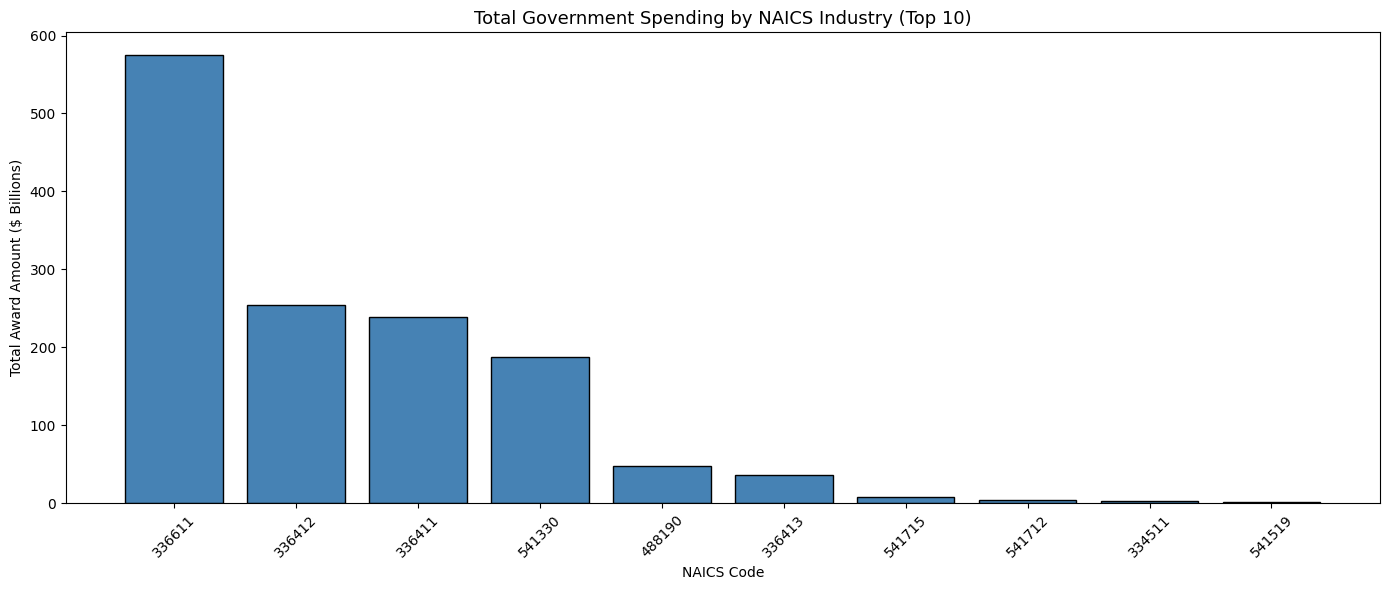

In [63]:
fig = plt.figure(figsize=(14, 6))

bar_data = (
    df_naics.groupby('naics_code')['total_award_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.bar(bar_data['naics_code'].astype(str),
        bar_data['total_award_amount'] / 1e9,
        color='steelblue', edgecolor='black')
plt.title('Total Government Spending by NAICS Industry (Top 10)', fontsize=13)
plt.xlabel('NAICS Code')
plt.ylabel('Total Award Amount ($ Billions)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Average Award Amount over Average Weekly Wage shows the amount that was awarded to the naics code over weekly wages.

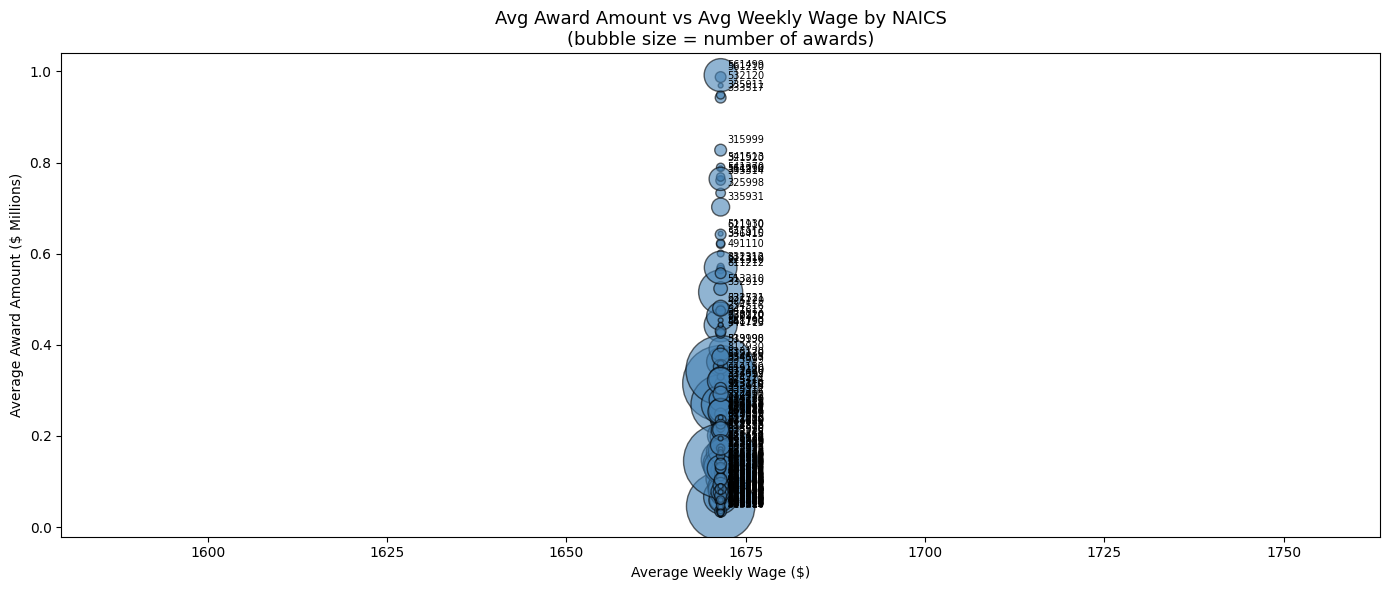

In [64]:
scatter_data = (
    df_naics.groupby('naics_code')
    .agg(avg_award=('avg_award_amount', 'mean'),
         avg_wage=('avg_weekly_wage', 'mean'),
         num_awards=('num_awards', 'sum'))
    .reset_index()
)
scatter_data['avg_award'] = pd.to_numeric(scatter_data['avg_award'], errors='coerce').fillna(0)
scatter_data['avg_wage'] = pd.to_numeric(scatter_data['avg_wage'], errors='coerce').fillna(0)
scatter_data['num_awards'] = pd.to_numeric(scatter_data['num_awards'], errors='coerce').fillna(1)

# Limit to avoid outliers and unreadable data
scatter_data = scatter_data[scatter_data['avg_award'] < 1000000]

fig = plt.figure(figsize=(14, 6))
plt.scatter(
    scatter_data['avg_wage'],
    scatter_data['avg_award'] / 1e6,
    s=scatter_data['num_awards'].astype(float) * 2,
    alpha=0.6,
    color='steelblue',
    edgecolors='black'
)
for _, row in scatter_data.iterrows():
    plt.annotate(str(row['naics_code']),
                 (row['avg_wage'], row['avg_award'] / 1e6),
                 textcoords='offset points', xytext=(5, 5), fontsize=7)

plt.title('Avg Award Amount vs Avg Weekly Wage by NAICS\n(bubble size = number of awards)', fontsize=13)
plt.xlabel('Average Weekly Wage ($)')
plt.ylabel('Average Award Amount ($ Millions)')
plt.tight_layout()
plt.savefig('spending_vs_wages.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 5: Reflection and Ethical Implications

In this project we made several formatting, filtering and data cleaning changes. Filtering out fields that won't be used in the analysis, trimming "CORPORATION" to "CORP.", searching for duplicates and updating the Department of Defense to reflect the officially reinstated title were among these transformations. To plot the data, further cleaning was needed. NaNs still existed in the wage data, which was preventing matplotlib from plotting the data. Even after the data had been visualized in the scatter plot, restrictions were needed to avoid including outliers. In the end, we were able to visualize Award Amount over Wages and FIPS code by storing multi-sourced data into a database. Much was learned about the different ways data can conatin inconsistencies and discrepencies even when taken directly from an API, flat file from a government webiste or from web scaping most of all.

Regulatory guidelines for the USASpending webite source are similar, if not identical to that of the U.S Treasury data and BLS Wage data under the <a href="https://fiscal.treasury.gov/foia.html">Freedom of Information Act"</a>. Risks created based on the transformations include incorrecly identifing a Recipient Name or neglecting to remove NaNs. Confusion can be avoided by only showing the data from this notebook to internal teams after ensuring it is cleaned to ones best ability. Reckless assumptions about a population could cause bias. This data was ethically sourced and verified, as it is from a credible government institution.

A few assumptions were made for this analysis, to limit the number of rows dealt with. All findings in this analysis were restricted to the state of Connecticut, which means all receiving Award Amounts should be for CT aside from contracts performed in another state but received by Connecticut. The timeframe of this analysis is restricted from early 2024 to current day. Award amounts will only include contracts that were active through, or modified after January 1st 2024.

To conclude, a data pipeline was created to pull in wage, government spending and monthly treasury statement data to analyze Award Amounts by Wage and FIPS code. This revealed which codes and wage groups were awarded the highest to lowest amounts within the scope of the analysis.




<b>Below are allthree dataframes in their current filtered, formatted and cleaned state.</b>

In [65]:
spending_df.head(5)

,internal_id,Award Amount,Award ID,Recipient Name,Recipient State Code,Awarding Agency,Start Date,End Date,Place of Performance State Code,Last Modified Date,Awarding Sub Agency,Funding Agency,Description,NAICS
0,309506838,3.465196e+10,N0002417C2100,ELECTRIC BOAT CORP.,None,Department of War,2017-02-14,2036-06-02,CT,2026-02-20 11:05:03,Department of the Navy,Department of War,SSN 802 AND 803 LONG LEAD TIME MATERIAL,336611
1,309506843,2.431381e+10,N0002417C2117,ELECTRIC BOAT CORP.,None,Department of War,2017-09-21,2031-12-31,CT,2025-11-26 10:27:56,Department of the Navy,Department of War,COLUMBIA CLASS DESIGN COMPLETION,541330
2,309505151,1.962774e+10,N0002412C2115,ELECTRIC BOAT CORP.,None,Department of War,2012-04-13,2026-03-01,CT,2025-12-04 11:03:38,Department of the Navy,Department of War,SSN 792 LONG LEAD TIME MATERIAL,336611
3,309504148,1.623878e+10,N0002409C2104,ELECTRIC BOAT CORP.,None,Department of War,2008-12-22,2023-08-31,CT,2025-11-17 09:29:09,Department of the Navy,Department of War,CONSTRUCTION OF VIRGINIA CLASS BLOCK III SUBMA...,336611
4,309501862,9.397332e+09,N0002403C2101,ELECTRIC BOAT CORP.,None,Department of War,2003-08-14,2025-05-06,CT,2025-05-13 15:18:06,Department of the Navy,Department of War,NaN,336611


In [66]:
treasury_df.head(5)

,Date,ClassID,Month,GrossReceipts,GrossOutlayAmt,DeficitSurplusAmt
1,2025-12-31,57633931,October,3.267702e+11,5.842203e+11,2.574500e+11
2,2025-12-31,57633935,November,3.017543e+11,6.685171e+11,3.667628e+11
3,2025-12-31,57633940,December,4.544147e+11,5.411463e+11,8.673162e+10
4,2025-12-31,57633942,January,5.132943e+11,6.419345e+11,1.286402e+11
5,2025-12-31,57633946,February,2.964237e+11,6.034409e+11,3.070172e+11


In [67]:
wage_df.head(5)

,area_fips,industry_code,year,qtr,qtrly_estabs,month1_emplvl,month2_emplvl,month3_emplvl,total_qtrly_wages,taxable_qtrly_wages,avg_wkly_wage
0,1000,10,2024,1,160709,2070184,2090389,2095004,32495265283,11568954825,1199
1,1000,10,2024,1,1265,57557,57838,57908,1425914334,0,1899
2,1000,10,2024,1,1426,102630,104771,105354,1719625744,236321,1269
3,1000,10,2024,1,3781,222364,222740,224268,2960877022,114839815,1021
4,1000,10,2024,1,154237,1687633,1705040,1707474,26388848183,11453878689,1194
